In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [77]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType

Load the data

In [32]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")
print(train_df.shape, val_df.shape, test_df.shape)
print(train_df.head())

(34944, 2) (7464, 2) (7484, 2)
      label                                             review
0  positive  best cheap GPS: The Garmin Etrex, at under $10...
1  positive  YOU MADE ME FEEL I WAS AYLA!: WHEN WILL #5 COM...
2  negative  So good we now buy Brother: Installing one of ...
3  positive  Powerful: Austin brings to life a part of the ...
4  positive  Tao terrific: This read is very informational ...


In [33]:
# Convert string labels to binary labels
label_to_id_map = {"negative": 0, "positive": 1}
id_to_label_map = {0: "negative", 1: "positive"}
train_df["label"] = train_df["label"].map(label_to_id_map)
val_df["label"] = val_df["label"].map(label_to_id_map)
test_df["label"] = test_df["label"].map(label_to_id_map)
print(train_df.head())

   label                                             review
0      1  best cheap GPS: The Garmin Etrex, at under $10...
1      1  YOU MADE ME FEEL I WAS AYLA!: WHEN WILL #5 COM...
2      0  So good we now buy Brother: Installing one of ...
3      1  Powerful: Austin brings to life a part of the ...
4      1  Tao terrific: This read is very informational ...


Load pretrained model and tokenizer

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [35]:
# Viewing the method of tokenization
encoded_text = tokenizer.encode("Hello World!")
print(encoded_text)
print(tokenizer.decode(encoded_text, skip_special_tokens=False))

[101, 7592, 2088, 999, 102]
[CLS] hello world! [SEP]


Tokenize text

In [36]:
def tokenize_function(text):
    return tokenizer(text["review"], padding="max_length", truncation=True)

# Convert pandas DataFrames to Dataset objects
train_df = Dataset.from_pandas(train_df)
val_df = Dataset.from_pandas(val_df)
test_df = Dataset.from_pandas(test_df)

tokenized_train_df = train_df.map(tokenize_function, batched=True)
tokenized_val_df = val_df.map(tokenize_function, batched=True)
tokenized_test_df = test_df.map(tokenize_function, batched=True)

Map:   0%|          | 0/34944 [00:00<?, ? examples/s]

Map:   0%|          | 0/7464 [00:00<?, ? examples/s]

Map:   0%|          | 0/7484 [00:00<?, ? examples/s]

In [37]:
print(tokenized_train_df)

Dataset({
    features: ['label', 'review', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 34944
})


Define metrics

In [49]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}

Hyperparameter tuning

In [67]:
#pip install optuna
import optuna

def objective(trial):
    # Define the hyperparameter search space
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Define training arguments
    training_args = TrainingArguments(
        output_dir=model_name,
        eval_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=1,
        weight_decay=0.01,
        fp16=True,
        save_strategy="epoch",
        disable_tqdm=False,
        report_to="none"
    )

    # Initialize Trainer and train model
    trainer = Trainer(
        model=model,
        args=training_args,
        compute_metrics=compute_metrics,
        train_dataset=tokenized_train_df,
        eval_dataset=tokenized_val_df
    )
    trainer.train()

    # Evaluate the model and return validation accuracy
    eval_results = trainer.evaluate()
    return eval_results["eval_accuracy"]

# Will be trying 5 different sets of hyperparameters
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print("Best hyperparameters:", study.best_params)

[I 2025-10-21 11:03:10,059] A new study created in memory with name: no-name-b6cf9f8c-a186-4731-b510-169670140b45


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.016000,0.336426,0.951233,0.951235


[I 2025-10-21 11:18:42,921] Trial 0 finished with value: 0.9512325830653805 and parameters: {'learning_rate': 3.940529219165891e-05, 'batch_size': 32}. Best is trial 0 with value: 0.9512325830653805.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.023100,0.389682,0.949223,0.949227


[I 2025-10-21 11:35:02,039] Trial 1 finished with value: 0.9492229367631297 and parameters: {'learning_rate': 4.412638867787352e-05, 'batch_size': 16}. Best is trial 0 with value: 0.9512325830653805.


...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.004400,0.497414,0.949089,0.949092


[I 2025-10-21 12:08:37,297] Trial 3 finished with value: 0.9490889603429796 and parameters: {'learning_rate': 1.6069762652056164e-05, 'batch_size': 8}. Best is trial 2 with value: 0.9517684887459807.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.003100,0.516443,0.948017,0.948022


[I 2025-10-21 12:24:54,908] Trial 4 finished with value: 0.9480171489817792 and parameters: {'learning_rate': 3.562054279599657e-05, 'batch_size': 32}. Best is trial 2 with value: 0.9517684887459807.


Best hyperparameters: {'learning_rate': 3.6257665915454894e-05, 'batch_size': 32}


Train the model using the best hyperparameters

In [68]:
model_name = "bert-finetuned-amazon-reviews"

# Define hyperaparamters
best_learning_rate = study.best_params["learning_rate"]
best_batch_size = study.best_params["batch_size"]

# Define training arguments
training_args = TrainingArguments(
    output_dir=model_name,
    eval_strategy="epoch",
    learning_rate=best_learning_rate,
    per_device_train_batch_size=best_batch_size,
    per_device_eval_batch_size=best_batch_size,
    num_train_epochs=1,
    weight_decay=0.01,
    fp16=True,
    save_strategy="epoch",
    disable_tqdm=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_train_df,
    eval_dataset=tokenized_val_df
)

# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.004600,0.472830,0.949089,0.949093


TrainOutput(global_step=1092, training_loss=0.006301155566295861, metrics={'train_runtime': 853.6896, 'train_samples_per_second': 40.933, 'train_steps_per_second': 1.279, 'total_flos': 9194152718499840.0, 'train_loss': 0.006301155566295861, 'epoch': 1.0})

Evaluate the model

In [69]:
# Evaluate on test data
preds_outputs = trainer.predict(tokenized_test_df)
preds_outputs.metrics

{'test_loss': 0.4345065951347351,
 'test_accuracy': 0.9512292891501871,
 'test_f1': 0.9512326117512785,
 'test_runtime': 67.992,
 'test_samples_per_second': 110.072,
 'test_steps_per_second': 3.442}

{0: 'negative', 1: 'positive'}
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      3670
           1       0.96      0.95      0.95      3814

    accuracy                           0.95      7484
   macro avg       0.95      0.95      0.95      7484
weighted avg       0.95      0.95      0.95      7484



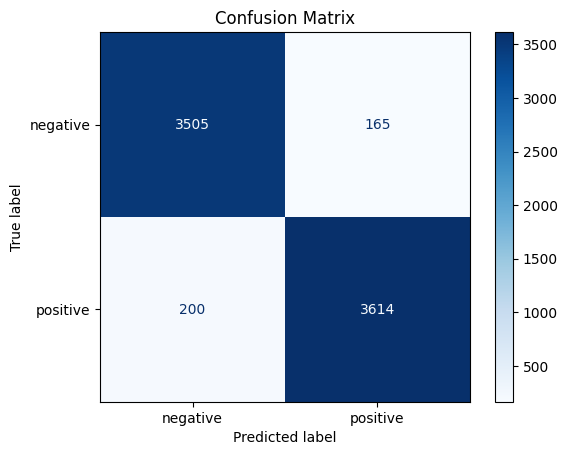

In [79]:
y_preds = np.argmax(preds_outputs.predictions, axis=1)
y_true = [label for label in tokenized_test_df["label"]]
print(id_to_label_map)
print(classification_report(y_true, y_preds, zero_division=0))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id_to_label_map.values()))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Error analysis

In [85]:
# Identify misclassified examples
misclassified_indices = [i for i, (true, pred) in enumerate(zip(y_true, y_preds)) if true != pred]
misclassified_reviews = [test_df["review"][i] for i in misclassified_indices]
misclassified_true_labels = [id_to_label_map[y_true[i]] for i in misclassified_indices]
misclassified_predicted_labels = [id_to_label_map[y_preds[i]] for i in misclassified_indices]

# Display a few misclassified examples
print(f"Number of misclassified examples: {len(misclassified_indices)}")
print("\nSample misclassified examples:")
for i in range(min(5, len(misclassified_indices))):
    print(f"Review: {misclassified_reviews[i]}")
    print(f"True label: {misclassified_true_labels[i]}")
    print(f"Predicted label: {misclassified_predicted_labels[i]}")
    print("-" * 50)

Number of misclassified examples: 365

Sample misclassified examples:
Review: ELI THE KING: I thought that this book was a good book. It was very interesting.I also thought that it had to much swearing in it.sincerely, The King Eli
True label: negative
Predicted label: positive
--------------------------------------------------
Review: Kindle version reformatted: This review concerns the Kindle edition. I paid $9.99! I would think at that price the publisher could have somebody edit the e-manuscript! There are numerous paragraph breaks where there should not be as well as some typoes. This detracts from the reading experience! Please fix! (the book itself is a fantasy classic and deserves better treatment than this slipshod editing)Edit 6/7/11 - looks like they reformatted the kindle version to deal with those errors. I don't know for sure if they caught them all because I haven't had a chance to look at it all - even if I had made bookmarks for the errors I wouldn't have been able to 

Adversarial testing

In [84]:
# Test with adversarial examples, such as oxymorons, spelling errors, conflicting sentiments, sarcasm
adversarial_inputs = ["This movie was surprisingly not bad!",
                      "This book is ecellent",
                      "This is good, but it is too expensive.",
                      "The service was great... (not really)"]

for text in adversarial_inputs:
    tokenized_inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
    tokenized_inputs = {name: tensor.to(device) for name, tensor in tokenized_inputs.items()}

    outputs = model(**tokenized_inputs)
    predictions = torch.argmax(outputs.logits, axis=1)
    print(f"Adversarial prediction for '{text}': {id_to_label_map[predictions.item()]}")

Adversarial prediction for 'This movie was surprisingly not bad!': positive
Adversarial prediction for 'This book is ecellent': positive
Adversarial prediction for 'This is good, but it is too expensive.': negative
Adversarial prediction for 'The service was great... (not really)': positive


Save the model and tokenizer

In [74]:
save_directory = "/content/drive/My Drive/bert_model_amazon"

In [75]:
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

('/content/drive/My Drive/bert_model_amazon/tokenizer_config.json',
 '/content/drive/My Drive/bert_model_amazon/special_tokens_map.json',
 '/content/drive/My Drive/bert_model_amazon/vocab.txt',
 '/content/drive/My Drive/bert_model_amazon/added_tokens.json',
 '/content/drive/My Drive/bert_model_amazon/tokenizer.json')